QUESTION 3



Slope: -0.03420 ± 0.00001 dex/kpc
Intercept: 9.1278 ± 0.0002 dex


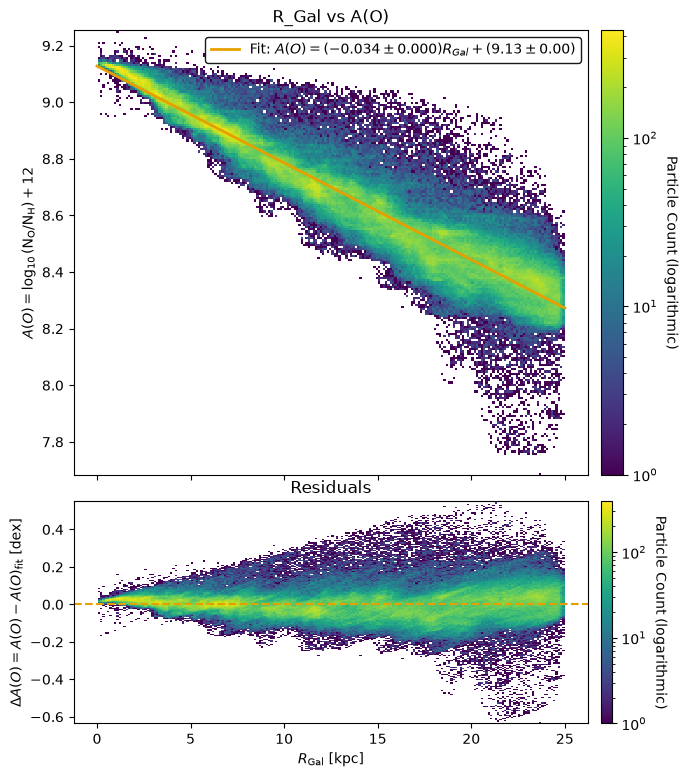

In [1]:
#Part 1 and 2 --- Radial Metallicity Relationship

import os
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.optimize import curve_fit

#Create the figures directory if it doesn't exist.
os.makedirs('figures', exist_ok=True)

#Read the FITS file and extract the relevant data columns.
file_path = 'data/nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits'
with fits.open(file_path) as hdul:
    data = hdul[1].data
    x_positions = np.array(data['x'], dtype=np.float64)
    y_positions = np.array(data['y'], dtype=np.float64)
    z_positions = np.array(data['z'], dtype=np.float64)
    AO_values = np.array(data['A_O'], dtype=np.float64)

#Calculate the galactocentric radius for each particle.
r_gal = np.sqrt(x_positions**2 + y_positions**2)

#Filter out invalid data points (NaN or infinite values) and those with R_Gal greater than 25 kpc.
mask = (r_gal < 25) & np.isfinite(r_gal) & np.isfinite(AO_values)
r_gal_filtered = r_gal[mask]
AO_values_filtered = AO_values[mask]
x_values_filtered = x_positions[mask]
y_values_filtered = y_positions[mask]

#Define a linear model function for curve fitting.
def linear_model(r, slope, intercept):
    return slope * r + intercept

#Perform curve fitting to find the best-fit slope and intercept for the linear model.
popt, pcov = curve_fit(linear_model, r_gal_filtered, AO_values_filtered, p0=[-0.5, 9.0])
slope, intercept = popt
slope_err, intercept_err = np.sqrt(np.diag(pcov))

#Determine the predicted A(O) values based on the fitted linear model and calculate the residuals.
AO_predicted = linear_model(r_gal_filtered, slope, intercept)
residuals = AO_values_filtered - AO_predicted

print(f"Slope: {slope:.5f} ± {slope_err:.5f} dex/kpc")
print(f"Intercept: {intercept:.4f} ± {intercept_err:.4f} dex")

#Create a two-panel figure to visualise the relationship between R_Gal and A(O), as well as the residuals of the fit.
fig, axes = plt.subplots(2, 1, figsize=(8, 9), sharex=True, 
                         gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.08})

#R_Gal vs A(O)
h1 = axes[0].hist2d(r_gal_filtered, AO_values_filtered, bins=[200,200], cmap='viridis', norm=LogNorm())
r_eval = np.linspace(0, 25, 200)
fit_label = f'Fit: $A(O) = ({slope:.3f} \\pm {slope_err:.3f}) R_{{Gal}} + ({intercept:.2f} \\pm {intercept_err:.2f})$'
axes[0].plot(r_eval, linear_model(r_eval, slope, intercept), color='#e69f00', label=fit_label, linewidth=2)
axes[0].set_ylabel(r'$A(O) = \log_{10}(\mathrm{N_O}/\mathrm{N_H}) + 12$')
axes[0].set_title('R_Gal vs A(O)')
axes[0].legend(loc='upper right', fontsize=10, frameon=True, facecolor='white', edgecolor='black', framealpha=0.9)
cbar0 = fig.colorbar(h1[3], ax=axes[0], pad=0.02)
cbar0.set_label('Particle Count (logarithmic)', rotation=270, labelpad=15)

#Residuals R_Gal vs Delta A(O)
h2 = axes[1].hist2d(r_gal_filtered, residuals, bins=[200, 200], cmap='viridis', norm=LogNorm())

axes[1].axhline(y=0, color='#e69f00', linestyle='--', linewidth=1.5)
axes[1].set_xlabel(r'$R_{\mathrm{Gal}}$ [kpc]')
axes[1].set_ylabel(r'$\Delta A(O) = A(O) - A(O)_{\mathrm{fit}}$ [dex]')
axes[1].set_title('Residuals')

#Add the colour bar for the residuals density
cbar1 = fig.colorbar(h2[3], ax=axes[1], pad=0.02)
cbar1.set_label('Particle Count (logarithmic)', rotation=270, labelpad=15)


In [2]:
#Part 3 --- Goodness of fit

#First, calculate the global RMS and MAE of the residuals (and the R-squared value) and print them to the console.
rms_global = np.sqrt(np.mean(residuals**2))
print(f"Global RMS of residuals: {rms_global:.5f} dex")
mae_global = np.mean(np.abs(residuals))
print(f"Global MAE of residuals: {mae_global:.5f} dex")
r2 = 1 - (np.sum(residuals**2) / np.sum((AO_values_filtered - np.mean(AO_values_filtered))**2))
print(f"R-squared: {r2:.5f}")

#Breakdown into subsets to find areas of local best fit.
for r_low, r_high, name in [(0, 4, "Inner (R < 4)"), (4, 15, "Mid-disk (4 <= R < 15)"), (15, 25, "Outer (R >= 15)")]:
    mask = (r_gal_filtered >= r_low) & (r_gal_filtered < r_high)
    subset_residuals = residuals[mask]
    print(f"{name}, RMS: {np.sqrt(np.mean(subset_residuals**2)):.5f} dex, MAE: {np.mean(np.abs(subset_residuals)):.5f} dex, Count: {len(subset_residuals)}, RMS/MAE ratio: {np.sqrt(np.mean(subset_residuals**2)) / np.mean(np.abs(subset_residuals)):.5f}")



Global RMS of residuals: 0.07265 dex
Global MAE of residuals: 0.05173 dex
R-squared: 0.91254
Inner (R < 4), RMS: 0.03097 dex, MAE: 0.02549 dex, Count: 48591, RMS/MAE ratio: 1.21505
Mid-disk (4 <= R < 15), RMS: 0.05906 dex, MAE: 0.04213 dex, Count: 211465, RMS/MAE ratio: 1.40194
Outer (R >= 15), RMS: 0.08727 dex, MAE: 0.06487 dex, Count: 251464, RMS/MAE ratio: 1.34524


Part 3 --- Goodness of fit

Overall, the linear model can be seen to fit the data well ($R^2$ = 0.9125, global RMS = 0.0727 dex). However, by breaking the model down into subsections by galactocentric cylindrical radius, we can better assess the behaviour and fit of the model in different galactic regions.

The Inner radius, defined as $R_{Gal}$ < 4 kpc, demonstrates the lowest RMS error and Mean Absolute Error (MAE) of the regions --- 0.0310 dex and 0.0255 dex, respectively. The ratio of these metrics (RMS/MAE) also falls within expectations at 1.22, noting that for a normal distribution, $\sqrt(\frac{\pi}{2}) \approx 1.253$, which indicates an absence of heavy outlier tails and points to a well-mixed interstellar medium.

Comparatively, the Mid-Disk and Outer regions produce progressively worse RMS and MAE results (rising to 0.0591 dex and 0.0873 dex RMS, respectively), as typically expected when moving from the denser regions of the galaxy to the more dispersed outskirts. However, the higher RMS/MAE ratio in the Mid-Disk (1.40) and Outer (1.35) regions suggests the presence of substantial outliers where the simple linear model struggles, driven by non-axisymmetric features such as enhanced enrichment along spiral arms and dilution from pristine gas accretion.

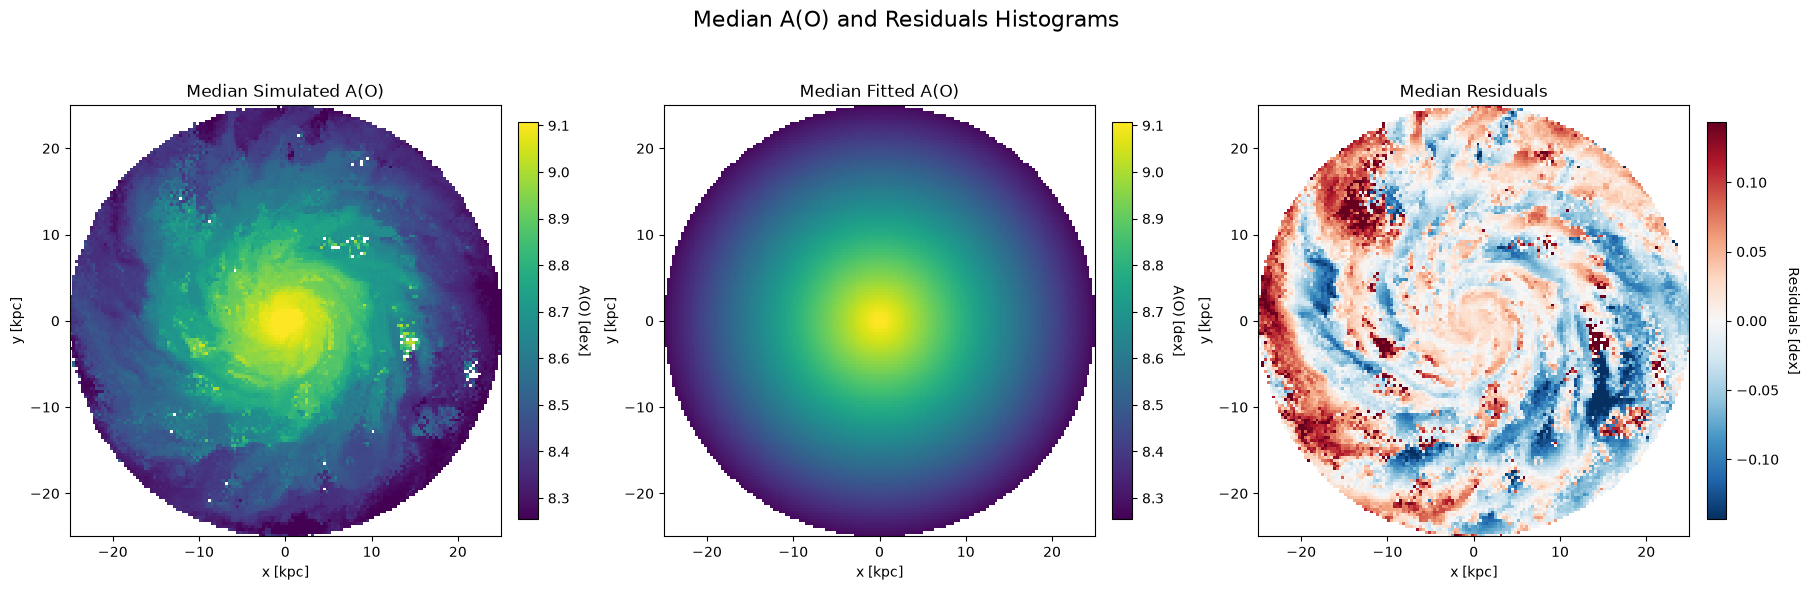

In [10]:
#Part 4 --- Histograms
from scipy.stats import binned_statistic_2d

#Define the bin edges for the histograms.
n_bins = 150
x_edges = np.linspace(-25, 25, n_bins + 1)
y_edges = np.linspace(-25, 25, n_bins + 1)

#Median Simulated A(O) Histogram
median_simulated, _, _, _ = binned_statistic_2d(x_values_filtered, y_values_filtered, 
                                            AO_values_filtered, statistic='median', bins=[x_edges, y_edges])

#Median Fitted A(O) Histogram
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
X_grid, Y_grid = np.meshgrid(x_centers, y_centers)
median_fitted = linear_model(np.sqrt(X_grid**2 + Y_grid**2), slope, intercept)
median_fitted[np.sqrt(X_grid**2 + Y_grid**2) > 25] = np.nan  #Mask out values outside the valid radius

#Median Residuals Histogram
median_residuals, _, _, _ = binned_statistic_2d(x_values_filtered, y_values_filtered, 
                                               residuals, statistic='median', bins=[x_edges, y_edges])

#Plotting the histograms.
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

vmin_ao = np.nanpercentile(AO_values_filtered, 2)
vmax_ao = np.nanpercentile(AO_values_filtered, 98)

vlim_residuals = np.nanpercentile(np.abs(residuals), 95)

#Plot Median Simulated A(O)
im0 = axes[0].pcolormesh(x_edges, y_edges, median_simulated.T, cmap='viridis', vmin=vmin_ao, vmax=vmax_ao)
axes[0].set_title('Median Simulated A(O)')
axes[0].set_xlabel('x [kpc]')
axes[0].set_ylabel('y [kpc]')
axes[0].set_aspect('equal')
cbar0 = fig.colorbar(im0, ax=axes[0], pad=0.04, fraction=0.046)
cbar0.set_label('A(O) [dex]', rotation=270, labelpad=15)

#Plot Median Fitted A(O)
im1 = axes[1].pcolormesh(x_edges, y_edges, median_fitted.T, cmap='viridis', vmin=vmin_ao, vmax=vmax_ao)
axes[1].set_title('Median Fitted A(O)')
axes[1].set_xlabel('x [kpc]')
axes[1].set_ylabel('y [kpc]')
axes[1].set_aspect('equal')
cbar1 = fig.colorbar(im1, ax=axes[1], pad=0.04, fraction=0.046)
cbar1.set_label('A(O) [dex]', rotation=270, labelpad=15)

#Plot Median Residuals
im2 = axes[2].pcolormesh(x_edges, y_edges, median_residuals.T, cmap='RdBu_r', vmin=-vlim_residuals, vmax=vlim_residuals)
axes[2].set_title('Median Residuals')
axes[2].set_xlabel('x [kpc]')
axes[2].set_ylabel('y [kpc]')
axes[2].set_aspect('equal')
cbar2 = fig.colorbar(im2, ax=axes[2], pad=0.04, fraction=0.046)
cbar2.set_label('Residuals [dex]', rotation=270, labelpad=15)

plt.suptitle('Median A(O) and Residuals Histograms', fontsize=16)
plt.savefig('figures/median_ao_residuals_histograms.png', dpi=300)
plt.show()


Part 5 --- Choice of Bins

The choice of 150 bins (that is, a 150 x 150 bin grid) was chosen to match the face-on span of the disk galaxy (50 kpc x 50 kpc) so as to achieve a realistic spatial resolution ($\approx 0.33$ kpc per bin) that best aligns with the physical scale of important interstellar features (such as spiral arm widths) whilst adhering to the hydrodynamic resolution limits of the NIHAO-UHD simulation. 

If fewer bins had been used, the spatial resolution would have been greatly diminished and as such a lot of the detail would be lost --- critical structural information would be smoothed out, thus inhibiting our ability to ascertain any enrichment tracks.

More bins would, however, introduce their own set of issues --- namely, a critical degree of spatial resolution (i.e. 0.1 kpc per bin) would introduce severe Poisson sampling noise. This would be a particular problem towards the outer regions of the disk, where gas partical surface density drops off steeply, as there wouldn't be enough particles in any given bin in these sparse regions. This would lead to artifacting (i.e. stochastic checkerboarding), empty/NaN bins and large statistical variances. You can, in fact, see some examples of this in the inter-arm regions of the Median Simulated A(O) plot --- note the white regions dotted around the interarm and underdense regions towards the galactic periphery that make it look like a worn-down sticker on a laptop lid.

Part 6 --- Residuals Analysis

The residuals plot reveals some very clear and coherent non-axisymmetric structures. Across the mid-regions of the disk, alternating bands of positive and negative residuals can be seen, clearly tracing the galactic spiral morphology. As gas enters the spiral arms, it undergoes compression and shock-induced star formation, which consequently leads to prompt in-situ enrichment from core-collapse Type II supernovae. This elevates the local oxygen abundance above the azimuthally averaged expectation, producing the distinct red tracks of positive residuals along the arm crests, while the quiescent interarm regions lag behind with negative residuals.

Further out towards the galactic outskirts, particularly along the lower and right-hand boundaries, broad coherent swathes of deep blue residuals indicate substantial under-enrichment. These patterns are characteristic of pristine or low-metallicity gas accretion from the circumgalactic medium (CGM), which dilutes the local interstellar medium before stellar processing can occur. Finally, localised bright overdensities --- such as the prominent red clump in the upper-left quadrant --- point to massive, self-enriching star-forming complexes.